In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/all_sessions.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(8058, 38)
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'AirTemp', 'TrackTemp', 'Humidity', 'Rainfall', 'Year', 'GrandPrix', 'Session']


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,DeletedReason,FastF1Generated,IsAccurate,AirTemp,TrackTemp,Humidity,Rainfall,Year,GrandPrix,Session
0,0 days 00:22:49.992000,VER,1,0 days 00:01:35.429000,2.0,1.0,NaN,NaN,0 days 00:00:30.535000,0 days 00:00:41.153000,...,NaN,False,True,26.989286,40.482143,12.261905,False,2023,Bahrain Grand Prix,FP1
1,0 days 00:44:47.890000,VER,1,0 days 00:01:33.375000,7.0,3.0,NaN,NaN,0 days 00:00:29.507000,0 days 00:00:40.148000,...,NaN,False,True,26.989286,40.482143,12.261905,False,2023,Bahrain Grand Prix,FP1
2,0 days 01:01:19.967000,VER,1,0 days 00:01:37.900000,10.0,4.0,NaN,NaN,0 days 00:00:31.366000,0 days 00:00:42.527000,...,NaN,False,True,26.989286,40.482143,12.261905,False,2023,Bahrain Grand Prix,FP1
3,0 days 01:02:57.947000,VER,1,0 days 00:01:37.980000,11.0,4.0,NaN,NaN,0 days 00:00:31.313000,0 days 00:00:42.513000,...,NaN,False,True,26.989286,40.482143,12.261905,False,2023,Bahrain Grand Prix,FP1
4,0 days 01:04:36.118000,VER,1,0 days 00:01:38.171000,12.0,4.0,NaN,NaN,0 days 00:00:31.434000,0 days 00:00:42.580000,...,NaN,False,True,26.989286,40.482143,12.261905,False,2023,Bahrain Grand Prix,FP1


In [2]:
df.isnull().sum()

Time                     0
Driver                   0
DriverNumber             0
LapTime                  0
LapNumber                0
Stint                    0
PitOutTime            8058
PitInTime             8011
Sector1Time              0
Sector2Time              0
Sector3Time              0
Sector1SessionTime       1
Sector2SessionTime       0
Sector3SessionTime       0
SpeedI1                  0
SpeedI2                  0
SpeedFL                 47
SpeedST                  0
IsPersonalBest           0
Compound                 0
TyreLife                 0
FreshTyre                0
Team                     0
LapStartTime             0
LapStartDate          8058
TrackStatus              0
Position              8058
Deleted               8058
DeletedReason         8058
FastF1Generated          0
IsAccurate               0
AirTemp                  0
TrackTemp                0
Humidity                 0
Rainfall                 0
Year                     0
GrandPrix                0
S

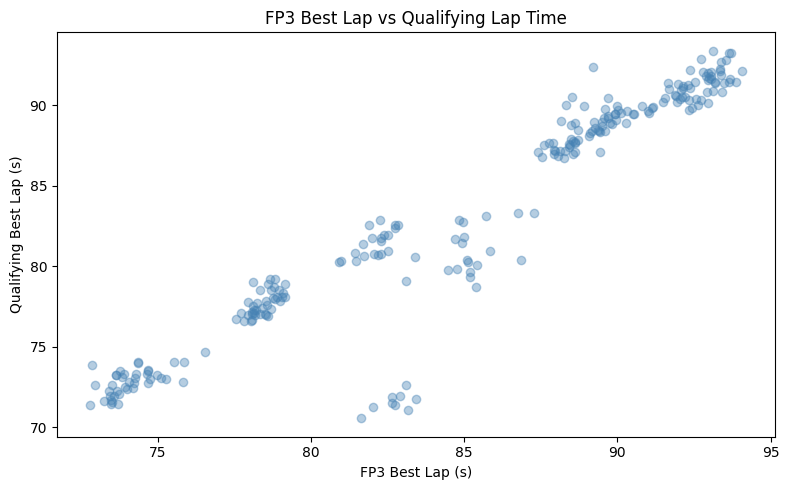

Chart saved to: /Users/harshiniratnakumar/Desktop/assets


In [5]:
import os

df['LapTime_s'] = pd.to_timedelta(df['LapTime']).dt.total_seconds()

fp3 = df[df['Session'] == 'FP3'].groupby(
    ['Year', 'GrandPrix', 'Driver'])['LapTime_s'].min().reset_index()
fp3.columns = ['Year', 'GrandPrix', 'Driver', 'FP3_best']

qual = df[df['Session'] == 'Q'].groupby(
    ['Year', 'GrandPrix', 'Driver'])['LapTime_s'].min().reset_index()
qual.columns = ['Year', 'GrandPrix', 'Driver', 'Quali_best']

combined = pd.merge(fp3, qual, on=['Year', 'GrandPrix', 'Driver']).dropna()

# Fix the path
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
assets_dir = os.path.join(base_dir, 'assets')
os.makedirs(assets_dir, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.scatter(combined['FP3_best'], combined['Quali_best'], alpha=0.4, color='steelblue')
plt.xlabel('FP3 Best Lap (s)')
plt.ylabel('Qualifying Best Lap (s)')
plt.title('FP3 Best Lap vs Qualifying Lap Time')
plt.tight_layout()
plt.savefig(os.path.join(assets_dir, 'fp3_vs_quali.png'))
plt.show()
print("Chart saved to:", assets_dir)

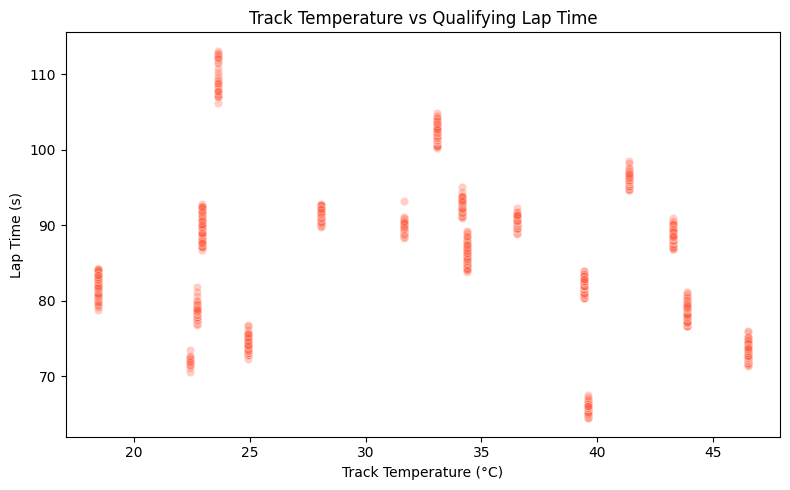

Chart saved!


In [6]:
q_data = df[df['Session'] == 'Q'].copy()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=q_data, x='TrackTemp', y='LapTime_s', alpha=0.3, color='tomato')
plt.xlabel('Track Temperature (°C)')
plt.ylabel('Lap Time (s)')
plt.title('Track Temperature vs Qualifying Lap Time')
plt.tight_layout()
plt.savefig(os.path.join(assets_dir, 'tracktemp_vs_laptime.png'))
plt.show()
print("Chart saved!")